In [1]:

## installo HGQ2 , inizialmente dava problemi perchè andava in conflitto con le versioni più recenti di Tensorflow. Cosi sembra funzionare.

!pip install HGQ2

In [2]:
## connessione al google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import random
import importlib
importlib.invalidate_caches()
# JAX runs the fastest for hgq in general based on our experience
# If you don't have jax, or if you want to use another backend, you can change this to 'tensorflow' or 'torch'
os.environ['KERAS_BACKEND'] = 'jax'
# tested for tensorflow, jax, and torch.
# For the best performance, we recommend using jax, or tensorflow with XLA (jit compile) enabled.
# Jit compilation for torch (torch dynamo) is not supported yet (may or may not work)

import keras
import numpy as np
from matplotlib import pyplot as plt

from hgq.layers import QConv2D, QDense, QMaxPool2D
from hgq.config import LayerConfigScope, QuantizerConfigScope
from hgq.config import QuantizerConfig, QuantizerConfigScope
from hgq.layers import QDense, QSoftmax
from hgq.utils.sugar import FreeEBOPs, PBar, BetaScheduler, ParetoFront

from keras.layers import *
from keras.models import Sequential, Model
from keras.optimizers import Adam, RMSprop

import pickle as pkl
from pathlib import Path

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')


In [4]:
FREQ = 150

In [5]:
help(QDense)

Help on class QDense in module hgq.layers.core.dense:

class QDense(hgq.layers.core.base.QLayerBaseSingleInput, keras.src.layers.core.dense.Dense)
 |  QDense(*args, **kwargs)
 |
 |  Method resolution order:
 |      QDense
 |      hgq.layers.core.base.QLayerBaseSingleInput
 |      hgq.layers.core.base.QLayerBase
 |      keras.src.layers.core.dense.Dense
 |      keras.src.layers.layer.Layer
 |      keras.src.backend.jax.layer.JaxLayer
 |      keras.src.ops.operation.Operation
 |      keras.src.saving.keras_saveable.KerasSaveable
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(
 |      self,
 |      units,
 |      activation=None,
 |      use_bias=True,
 |      kernel_initializer='glorot_uniform',
 |      bias_initializer='zeros',
 |      kernel_regularizer=None,
 |      bias_regularizer=None,
 |      activity_regularizer=None,
 |      kernel_constraint=None,
 |      bias_constraint=None,
 |      kq_conf: None | hgq.quantizer.config.QuantizerConfig = None,
 |      iq_

In [6]:
help(input)

Help on method raw_input in module ipykernel.kernelbase:

raw_input(prompt='') method of google.colab._kernel.Kernel instance
    Forward raw_input to frontends

    Raises
    ------
    StdinNotImplementedError if active frontend doesn't support stdin.



In [7]:
# ================================================================
# GÉOMÉTRIE : fonctions copiées de cellmap_visualizer
# (à lancer une seule fois après le chargement du drive)
# ================================================================
import pandas as pd

df_cellmap = pd.read_csv("/content/drive/MyDrive/project_files/cellmap.csv")

def rank_bin(values, n_bins):
    order = np.argsort(np.argsort(values))
    n = len(values)
    return np.minimum((order * n_bins) // n, n_bins - 1)

DAM_SHAPES = {0: (21, 3), 1: (21, 3), 2: (21, 3), 3: (17, 4), 4: (17, 4)}

def build_dam_grid_lookup_v7(df_cellmap, dam_shapes):
    lookup = {}
    shapes_used = {}
    for sec in range(6):
        sec_df = df_cellmap[df_cellmap["sector"] == sec].copy()
        sec_df["subsec"] = sec_df["pdu"] // 42
        sec_df["subpdu"] = sec_df["pdu"] % 42
        for n in range(5):
            n_rows, n_cols = dam_shapes[n]
            sub = sec_df[sec_df["subsec"] == n]
            centroids = sub.groupby("subpdu")[["lx", "ly"]].mean().reset_index()
            subpdu = centroids["subpdu"].astype(int).values
            pts = centroids[["lx", "ly"]].values
            pts_c = pts - pts.mean(axis=0)
            cov = np.cov(pts_c.T)
            eigvals, eigvecs = np.linalg.eigh(cov)
            order = np.argsort(eigvals)[::-1]
            eigvecs = eigvecs[:, order]
            proj = pts_c @ eigvecs
            gx = rank_bin(proj[:, 0], n_rows)
            gy = rank_bin(proj[:, 1], n_cols)
            cell_map = {}
            for i, ch in enumerate(subpdu):
                cell_map.setdefault((int(gx[i]), int(gy[i])), []).append(ch)
            lookup[(sec, n)] = cell_map
            shapes_used[(sec, n)] = (n_rows, n_cols)
    return lookup, shapes_used

lookup, shapes_used = build_dam_grid_lookup_v7(df_cellmap, DAM_SHAPES)
print("Lookup OK — shapes_used exemple:", shapes_used[(0,0)], shapes_used[(0,3)])

Lookup OK — shapes_used exemple: (21, 3) (17, 4)


In [8]:
import os

path = "/content/drive/MyDrive/project_files/input_time_4bins/"
if os.path.exists(path):
    print("Folder found! Files inside:")
    print(os.listdir(path))
else:
    print("The system cannot find the path specified. Check your folder names!")

Folder found! Files inside:
['noise_data_150kHz_timingaware.npy', 'signal_data_150kHz_timingaware.npy']


In [9]:
# ================================================================
# CHARGEMENT DES DONNÉES TIMINGAWARE + PROJECTION SUR LA GRILLE CNN
# ================================================================

def training_testing_data_split_ALCOR_optimized(
    random_state=42,
    signal_data="../training_datasets/20250107_input_signal_10kHzNoise_0to100.npy",
    noise_data="../training_datasets/20250107_input_noise_10kHzNoise_0to100.npy",
    dtype=np.float32,
    use_mmap=True,          # True par défaut : ne coûte jamais plus cher que False
    max_samples=None        # nouveau : plafond d'événements par classe
):
    mmap_mode = 'r' if use_mmap else None
    signal_mmap = np.load(signal_data, mmap_mode=mmap_mode)
    noise_mmap  = np.load(noise_data,  mmap_mode=mmap_mode)

    available_samples = min(len(signal_mmap), len(noise_mmap))
    n_samples = min(available_samples, max_samples) if max_samples is not None else available_samples
    print(f"Chargement de {n_samples} événements par classe (total: {n_samples*2})...")

    # slice AVANT le cast dtype -> seule la portion utile est matérialisée en RAM
    signal_inputs = signal_mmap[:n_samples].astype(dtype)
    noise_inputs  = noise_mmap[:n_samples].astype(dtype)

    X_total = np.concatenate((noise_inputs, signal_inputs), axis=0)
    y_noise  = np.zeros(len(noise_inputs), dtype=dtype)
    y_signal = np.ones(len(signal_inputs), dtype=dtype)
    y_total  = np.concatenate((y_noise, y_signal), axis=0)
    index_total = np.arange(len(y_total))

    X_train, X_tmp, y_train, y_tmp, idx_train, idx_tmp = train_test_split(
        X_total, y_total, index_total, test_size=0.1, random_state=random_state, shuffle=True)
    X_test, X_val, y_test, y_val, idx_test, idx_val = train_test_split(
        X_tmp, y_tmp, idx_tmp, test_size=0.1, random_state=random_state, shuffle=True)

    return X_train, X_val, X_test, y_train, y_val, y_test, idx_train, idx_val, idx_test

def scatter_dam_to_grid_timing(X_dam_timing, cell_map, shape, n_channels=4):
    """
    X_dam_timing : (N, 42, n_channels) — 42 PDUs × n_channels bins temporels
    Retourne     : (N, n_rows, n_cols, n_channels)
    """
    n_rows, n_cols = shape
    N = X_dam_timing.shape[0]
    img = np.zeros((N, n_rows, n_cols, n_channels), dtype=np.float32)
    for (gx, gy), chans in cell_map.items():
        # Sommer les contributions de tous les canaux qui partagent cette case
        img[:, gx, gy, :] += X_dam_timing[:, chans, :].sum(axis=1)
    return img

def build_cnn_inputs(X, lookup, shapes_used, n_channels=4):
    """
    X : (N, 30, 42*n_channels) — aplati tel que sorti du .npy
     ou (N, 30, 42, n_channels) — déjà reshapé
    Retourne : liste de 30 tenseurs (N, n_rows, n_cols, n_channels)
    """
    # Désaplatir automatiquement si nécessaire
    if X.ndim == 3:
        N, n_dam, flat = X.shape
        assert flat == 42 * n_channels, \
            f"Dimension inattendue : {flat} ≠ 42×{n_channels}={42*n_channels}. " \
            f"Vérifie n_channels ou la shape du .npy."
        X = X.reshape(N, n_dam, 42, n_channels)

    N = X.shape[0]
    grids = []
    for sec in range(6):
        for n in range(5):
            dam_idx = sec * 5 + n
            cell_map = lookup[(sec, n)]
            n_rows, n_cols = shapes_used[(sec, n)]
            X_dam = X[:, dam_idx, :, :]   # (N, 42, n_channels)
            img = np.zeros((N, n_rows, n_cols, n_channels), dtype=np.float32)
            for (gx, gy), chans in cell_map.items():
                img[:, gx, gy, :] += X_dam[:, chans, :].sum(axis=1)
            grids.append(img)
    return grids

target_dir = "/content/drive/MyDrive/project_files/input_time_4bins/"

X_train, X_val, X_test, y_train, y_val, y_test, index_train, index_val, index_test = \
    training_testing_data_split_ALCOR_optimized(
        random_state=69,
        signal_data=f"{target_dir}signal_data_{FREQ}kHz_timingaware.npy",
        noise_data =f"{target_dir}noise_data_{FREQ}kHz_timingaware.npy"
    )


print("Shape brute chargée :", X_train.shape)

# Si le .npy est aplati (N, 30, 168) :
X_train = X_train.reshape(X_train.shape[0], 30, 42, 4)
X_test  = X_test.reshape(X_test.shape[0],   30, 42, 4)
X_val   = X_val.reshape(X_val.shape[0],     30, 42, 4)

print("Shape finale :", X_train.shape)
N_CHANNELS = X_train.shape[-1]   # = 4
print(f"N_CHANNELS={N_CHANNELS}")

Chargement de 79000 événements par classe (total: 158000)...
Shape brute chargée : (142200, 30, 168)
Shape finale : (142200, 30, 42, 4)
N_CHANNELS=4


In [10]:

# --- Projection sur grilles CNN ---
print("Projection sur grilles CNN...")
model_input_train = build_cnn_inputs(X_train, lookup, shapes_used, n_channels=N_CHANNELS)
model_input_test  = build_cnn_inputs(X_test,  lookup, shapes_used, n_channels=N_CHANNELS)
model_input_val   = build_cnn_inputs(X_val,   lookup, shapes_used, n_channels=N_CHANNELS)

print(f"model_input_train[0].shape  (DAM 0,  21×3×4) : {model_input_train[0].shape}")
print(f"model_input_test[14].shape (DAM 14, 17×4×4) : {model_input_test[14].shape}")
# Attendu :
# model_input_train[0].shape  → (N, 21, 3, 4)
# model_input_train[14].shape → (N, 17, 4, 4)  (DAM n=5 du secteur 3)

Projection sur grilles CNN...
model_input_train[0].shape  (DAM 0,  21×3×4) : (142200, 21, 3, 4)
model_input_test[14].shape (DAM 14, 17×4×4) : (14220, 17, 4, 4)


In [12]:
# ================================================================
# VÉRIFICATION DU .NPY ET DU DÉSAPLATISSEMENT
# ================================================================
import numpy as np

# 1. Charger un petit échantillon sans mmap pour inspection
tmp = np.load(
    f"{target_dir}signal_data_{FREQ}kHz_timingaware.npy",
    mmap_mode='r'
)
print("Shape brute du .npy :", tmp.shape)
# Attendu : (N, 30, 168)

# 2. Désaplatir
tmp_4d = tmp[:10].reshape(10, 30, 42, 4)  # 10 événements test
print("Shape après reshape  :", tmp_4d.shape)
# Attendu : (10, 30, 42, 4)

# 3. Vérifier la conservation du signal — somme identique avant/après
assert np.allclose(tmp[:10].sum(), tmp_4d.sum()), \
    "ERREUR : la somme totale change après reshape — ordre des axes incorrect"
print("✓ Conservation du signal OK (somme identique avant/après reshape)")

# 4. Vérifier la correspondance entre l'aplati et le 4D
#    index aplati = pdu*4 + bin  →  tmp[ev, dam, pdu*4 + bin] == tmp_4d[ev, dam, pdu, bin]
ev, dam, pdu, bin_t = 0, 5, 17, 2
val_flat = tmp[ev, dam, pdu * 4 + bin_t]
val_4d   = tmp_4d[ev, dam, pdu, bin_t]
print(f"\nTest d'indexation — event={ev}, dam={dam}, pdu={pdu}, bin={bin_t}")
print(f"  Valeur depuis aplati [pdu*4+bin] : {val_flat}")
print(f"  Valeur depuis 4D     [pdu, bin]  : {val_4d}")
assert val_flat == val_4d, \
    f"ERREUR : valeurs différentes ({val_flat} vs {val_4d}) — l'ordre pdu/bin est inversé"
print("✓ Ordre pdu×bin correct : index_aplati = pdu*4 + bin")

# 5. Vérifier la structure temporelle — le signal doit être concentré en bin0/bin1
#    et le bruit doit être plat
#    (charge juste les 100 premiers événements pour ce test)
tmp_signal = np.load(
    f"{target_dir}signal_data_{FREQ}kHz_timingaware.npy", mmap_mode='r'
)[:100].reshape(100, 30, 42, 4)
tmp_noise = np.load(
    f"{target_dir}noise_data_{FREQ}kHz_timingaware.npy", mmap_mode='r'
)[:100].reshape(100, 30, 42, 4)

hits_by_bin_signal = tmp_signal.sum(axis=(0, 1, 2))  # (4,) — total hits par bin
hits_by_bin_noise  = tmp_noise.sum(axis=(0, 1, 2))   # (4,)

print("\nDistribution des hits par bin temporel (100 événements) :")
print(f"  Signal : bin0={hits_by_bin_signal[0]:.0f}  "
      f"bin1={hits_by_bin_signal[1]:.0f}  "
      f"bin2={hits_by_bin_signal[2]:.0f}  "
      f"bin3={hits_by_bin_signal[3]:.0f}")
print(f"  Noise  : bin0={hits_by_bin_noise[0]:.0f}  "
      f"bin1={hits_by_bin_noise[1]:.0f}  "
      f"bin2={hits_by_bin_noise[2]:.0f}  "
      f"bin3={hits_by_bin_noise[3]:.0f}")

# Signal attendu : bin0 >> bin2, bin3 (pic à ~1 ns puis décroissance)
# Noise attendu : distribution approximativement plate sur les 4 bins
ratio_signal = hits_by_bin_signal[0] / (hits_by_bin_signal.mean() + 1e-9)
ratio_noise  = hits_by_bin_noise[0]  / (hits_by_bin_noise.mean()  + 1e-9)
print(f"\n  Ratio bin0/moyenne — signal : {ratio_signal:.2f}  (attendu >> 1)")
print(f"  Ratio bin0/moyenne — noise  : {ratio_noise:.2f}   (attendu ≈ 1)")

if ratio_signal > 1.5:
    print("✓ Structure temporelle cohérente : signal concentré en bin0")
else:
    print("⚠ Ratio signal faible — vérifier la normalisation temporelle dans le dataset")

print("\n✓ Toutes les vérifications passées — le .npy est correct et le reshape est valide")

Shape brute du .npy : (79000, 30, 168)
Shape après reshape  : (10, 30, 42, 4)
✓ Conservation du signal OK (somme identique avant/après reshape)

Test d'indexation — event=0, dam=5, pdu=17, bin=2
  Valeur depuis aplati [pdu*4+bin] : 0
  Valeur depuis 4D     [pdu, bin]  : 0
✓ Ordre pdu×bin correct : index_aplati = pdu*4 + bin

Distribution des hits par bin temporel (100 événements) :
  Signal : bin0=15735  bin1=15622  bin2=13787  bin3=14737
  Noise  : bin0=12071  bin1=12215  bin2=12258  bin3=12276

  Ratio bin0/moyenne — signal : 1.05  (attendu >> 1)
  Ratio bin0/moyenne — noise  : 0.99   (attendu ≈ 1)
⚠ Ratio signal faible — vérifier la normalisation temporelle dans le dataset

✓ Toutes les vérifications passées — le .npy est correct et le reshape est valide


In [11]:
from keras.regularizers import l2

def Keras_MLP_damI(string, l2_reg=1e-4):

    inTnsr  = Input(shape=(42,), name="input"+string) # default dtype is float32
    #inTnsr  = Input(shape=(grid_size*grid_size,), name=string+"input") # default dtype is float32

    #x = Dense(64, name =string+'fc3')(inTnsr)
    #x = Activation("relu", name=string+'act3') (x)

    x = QDense(32, name ='fc4_'+string, activation='relu', kernel_regularizer=l2(l2_reg))(inTnsr)
    #x = Activation("relu", name='act4_'+string) (x)

    x = QDense(16, name ='fc5_'+string, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    #x = Activation("relu", name='act5_'+string) (x)

    outTnsr = QDense(8, name ='fc6_'+string, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    #outTnsr = Activation("relu", name='act6_'+string) (x)

    model = Model(inputs=inTnsr, outputs=outTnsr)
    return model

def Keras_MLP_damI_time(string):

    inTnsr  = Input(shape=(42*4,), name="input"+string) # default dtype is float32
    #inTnsr  = Input(shape=(grid_size*grid_size,), name=string+"input") # default dtype is float32

    #x = Dense(64, name =string+'fc3')(inTnsr)
    #x = Activation("relu", name=string+'act3') (x)

    x = QDense(32*4, name ='fc4_'+string, activation='relu')(inTnsr)

    x = QDense(64, name ='fc5_'+string, activation='relu')(x)

    x = QDense(32, name ='fc6_'+string, activation='relu')(x)

    x = QDense(16, name ='fc7_'+string, activation='relu')(x)

    outTnsr = QDense(8, name ='fc8_'+string, activation='relu')(x)

    model = Model(inputs=inTnsr, outputs=outTnsr)
    return model

def Keras_MLP_sector(string):

    inTnsr  = Input(shape=(40,), name="sector_input"+string) # default dtype is float32
    #inTnsr  = Input(shape=(grid_size*grid_size,), name=string+"input") # default dtype is float32

   # x = Dense(64, name =string+'fc3')(inTnsr)
   # x = Activation("relu", name=string+'act3') (x)
    x = QDense(20, name ='sector_fc4_'+string)(inTnsr)
    x = Activation("relu", name='sector_act4_'+string) (x)
    x = QDense(16, name ='sector_fc5_'+string)(x)
    x = Activation("relu", name='sector_act5_'+string) (x)
    x = QDense(4, name ='sector_fc6_'+string)(x)
    x = Activation("relu", name='sector_act6_'+string) (x)
    x = QDense(1, name ='sector_fc7_'+string)(x)
    outTnsr = Activation("sigmoid", name='sector_act7_'+string) (x)

    model = Model(inputs=inTnsr, outputs=outTnsr)
    return model


def Keras_CNN_damI(string):
    inTnsr = Input(shape=(42,4,1,),name=string+"input")
    x = QConv2D(filters = 16, kernel_size = 4, padding = 'same', name=string+'conv1', activation='relu')(inTnsr)
    #x = Activation("relu", name=string+'act4') (x)
    x = QMaxPool2D (pool_size = 2, strides = 2, padding ='same', name = string+'maxp1') (x)
    x = QConv2D(filters   = 16, kernel_size = 4, padding ='same', name = string+'conv2',activation='relu') (x)
    #x = Activation("relu", name = string+'act5' ) (x)
    x = QMaxPool2D (pool_size = 2, strides = 2, padding ='same', name = string+'maxp2') (x)
    x = Flatten(name = string+'flatten')(x)
    x = QDense(16, name = string+'fc4',activation='relu') (x)
    #x = Activation("relu", name = string+'act6' ) (x)
    outTnsr = QDense(8, name = string+'fc5', activation='relu') (x)

    model  = Model(inputs=inTnsr, outputs=outTnsr)
    return model

# ================================================================
# DÉFINITION DES MODÈLES CNN
# ================================================================

def Keras_CNN_damI_21x3(string, n_channels=4, l2_reg=1e-4):
    """
    DAM NN pour les DAMs 0, 1, 2 de chaque secteur (shape 21×3).
    1 seul bloc Conv2D + Pool : justifié car la grille est déjà très étroite
    sur l'axe court (3 colonnes), un 2e bloc n'aurait rien à extraire.
    Kernel (3,3) avec padding='same' → couvre toute la largeur dès le 1er bloc.
    """
    inTnsr = Input(shape=(21, 3, n_channels), name="input" + string)
    # Conv2D spatio-temporelle : apprend simultanément la localité spatiale
    # (l'arc Cherenkov sur les 21 positions) et la structure temporelle (4 bins)
    x = QConv2D(filters=4, kernel_size=(3, 3), padding='same',
                activation='relu', name='conv1_' + string)(inTnsr)
    # output : (21, 3, 4)
    x = QMaxPool2D(pool_size=(2, 1), strides=(2, 1),
                   name='pool1_' + string)(x)
    # output : (10, 3, 4)  — on réduit seulement l'axe long
    # Pool asymétrique : (2,1) réduit l'axe long de moitié mais préserve
    # l'axe court (3 → 3) pour ne pas écraser la dimension spatiale étroite
    x = Flatten(name='flat_' + string)(x)
    # output : 10×3×4 = 120 valeurs
    outTnsr = QDense(8, activation='relu', name='fc_' + string, kernel_regularizer=l2(l2_reg))(x)
    # output : 8 features — même dimension que le MLP actuel → Sector NN inchangé

    model = Model(inputs=inTnsr, outputs=outTnsr)
    return model


def Keras_CNN_damI_17x4(string, n_channels=4, l2_reg=1e-4):
    """
    DAM NN pour les DAMs 3, 4 de chaque secteur (shape 17×4).
    Même logique que 21×3, adapté à la grille plus large sur l'axe court.
    Pool asymétrique (2,2) : réduit les deux axes.
    """
    inTnsr = Input(shape=(17, 4, n_channels), name="input" + string)
    x = QConv2D(filters=4, kernel_size=(3, 3), padding='same',
                activation='relu', name='conv1_' + string)(inTnsr)
    # output : (17, 4, 4)
    x = QMaxPool2D(pool_size=(2, 2), strides=(2, 2),
                   name='pool1_' + string)(x)
    # output : (8, 2, 4) = 64 valeurs
    x = Flatten(name='flat_' + string)(x)
    outTnsr = QDense(8, activation='relu', name='fc_' + string, kernel_regularizer=l2(l2_reg))(x)

    model = Model(inputs=inTnsr, outputs=outTnsr)
    return model


def Keras_CNN_DAMandTP_mixed(dam_models):
    """
    Modèle complet : 30 DAM CNNs (21×3 ou 17×4) → 6 Sector MLPs → Aggregation.
    dam_models : liste de 30 modèles DAM dans l'ordre sec*5+subsec.
    """
    outputs = [m.output for m in dam_models]

    # Regrouper par secteur (5 DAMs par secteur)
    sector_outputs = []
    for sec in range(6):
        sec_outs = outputs[sec*5 : sec*5+5]          # 5 × (N, 8)
        x = Concatenate(name=f'concatenate_{sec}')(sec_outs)  # (N, 40)

        # Sector MLP — inchangé par rapport au code actuel
        x = QDense(20, activation='relu', name=f'sector_fc4_{sec}')(x)
        x = QDense(16, activation='relu', name=f'sector_fc5_{sec}')(x)
        y = QDense(4,  activation='relu', name=f'sector_fc6_{sec}')(x)
        sector_outputs.append(y)

    # Aggregation
    y = Concatenate(name='concatenate_6')(sector_outputs)  # (N, 24)
    outTnsr = QDense(1, activation='sigmoid', name='fc8_damII')(y)

    all_inputs = [m.input for m in dam_models]
    model = Model(inputs=all_inputs, outputs=outTnsr)
    return model


def model_inter_process_CNN(n_channels=4, verbose=False):
    """
    Construit le modèle complet CNN avec les bonnes shapes par DAM.
    DAMs 0,1,2 de chaque secteur → 21×3×n_channels
    DAMs 3,4   de chaque secteur → 17×4×n_channels
    """
    dam_models = []
    for sec in range(6):
        for n in range(5):
            dam_idx = sec * 5 + n
            s = str(dam_idx)
            if n in [0, 1, 2]:
                dam_models.append(Keras_CNN_damI_21x3(s, n_channels=n_channels))
            else:  # n in [3, 4]
                dam_models.append(Keras_CNN_damI_17x4(s, n_channels=n_channels))

    model = Keras_CNN_DAMandTP_mixed(dam_models)
    model.compile()

    if verbose:
        model.summary()

    return model

# Instanciation
MODEL_SEC = model_inter_process_CNN(n_channels=N_CHANNELS, verbose=True)

Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input0 (InputLayer) │ (None, 21, 3, 4)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input1 (InputLayer) │ (None, 21, 3, 4)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input2 (InputLayer) │ (None, 21, 3, 4)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input3 (InputLayer) │ (None, 17, 4, 4)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input4 (InputLayer) │ (None, 17, 4, 4)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input5 (InputLayer) │ (None, 21, 3, 4)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input6 (InputLayer) │ (None, 21, 3, 4)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input7 (InputLayer) │ (None, 21, 3, 4)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input8 (InputLayer) │ (None, 17, 4, 4)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input9 (InputLayer) │ (None, 17, 4, 4)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input10             │ (None, 21, 3, 4)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input11             │ (None, 21, 3, 4)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input12             │ (None, 21, 3, 4)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input13             │ (None, 17, 4, 4)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input14             │ (None, 17, 4, 4)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input15             │ (None, 21, 3, 4)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input16             │ (None, 21, 3, 4)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input17             │ (None, 21, 3, 4)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input18             │ (None, 17, 4, 4)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input19             │ (None, 17, 4, 4)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 199,322 (618.99 KB)

 Trainable params: 124,826 (487.60 KB)

 Non-trainable params: 74,496 (131.39 KB)

In [12]:
import jax

jax.config.update('jax_default_matmul_precision', 'highest')

In [ ]:
# ================================================================
# ENTRAÎNEMENT
# ================================================================

from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from hgq.utils.sugar import FreeEBOPs

# First, set up quantization configuration
# For weights, use SAT_SYM overflow mode
with QuantizerConfigScope(q_type='kif', place='weight', overflow_mode='SAT_SYM', round_mode='RND'):
    # For activations, use different config
    with QuantizerConfigScope(q_type='kif', place='datalane', overflow_mode='WRAP', round_mode='RND'):
        with LayerConfigScope(enable_ebops=True, beta0=1e-5):
            # Create model with quantized layers
            model = MODEL_SEC

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-1),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]
)

early_stop = EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)
reduce_on_plateau = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1
)
ebops = FreeEBOPs()


history = model.fit(
    model_input_train,
    y_train,
    epochs=150,
    batch_size=2000,
    verbose=True,
    validation_data=[model_input_val, y_val],
    shuffle=True,
    validation_batch_size=1000,
    class_weight={0: 1.0, 1: 1.0},
    callbacks=[early_stop, reduce_on_plateau, ebops]
)

Epoch 1/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 300s 7s/step - accuracy: 0.4996 - loss: nan - val_accuracy: 0.4867 - val_loss: 8.3588 - learning_rate: 0.1000 - ebops: 18122215.0000
Epoch 2/150


In [ ]:
import numpy as np

#model_input_val, model_input_test = model_inputs_for_NN(X_val, X_test)

y_pred = model.predict(model_input_test,batch_size=1000)
print("y_pred shape: ", np.asarray(y_pred).reshape)

In [ ]:
def Keras_MLP_DAMandTP(Keras_MLP_damI,Keras_MLP_sector):

    x0 = Keras_MLP_damI[0].output
    x1 = Keras_MLP_damI[1].output
    x2 = Keras_MLP_damI[2].output
    x3 = Keras_MLP_damI[3].output
    x4 = Keras_MLP_damI[4].output
    x5 = Keras_MLP_damI[5].output
    x6 = Keras_MLP_damI[6].output
    x7 = Keras_MLP_damI[7].output
    x8 = Keras_MLP_damI[8].output
    x9 = Keras_MLP_damI[9].output
    x10 = Keras_MLP_damI[10].output
    x11 = Keras_MLP_damI[11].output
    x12 = Keras_MLP_damI[12].output
    x13 = Keras_MLP_damI[13].output
    x14 = Keras_MLP_damI[14].output
    x15 = Keras_MLP_damI[15].output
    x16 = Keras_MLP_damI[16].output
    x17 = Keras_MLP_damI[17].output
    x18 = Keras_MLP_damI[18].output
    x19 = Keras_MLP_damI[19].output
    x20 = Keras_MLP_damI[20].output
    x21 = Keras_MLP_damI[21].output
    x22 = Keras_MLP_damI[22].output
    x23 = Keras_MLP_damI[23].output
    x24 = Keras_MLP_damI[24].output
    x25 = Keras_MLP_damI[25].output
    x26 = Keras_MLP_damI[26].output
    x27 = Keras_MLP_damI[27].output
    x28 = Keras_MLP_damI[28].output
    x29 = Keras_MLP_damI[29].output

    x_sec0 = Concatenate(name ='concatenate_0')([x0,x1,x2,x3,x4])
    x_sec1 = Concatenate(name ='concatenate_1')([x5,x6,x7,x8,x9])
    x_sec2 = Concatenate(name ='concatenate_2')([x10,x11,x12,x13,x14])
    x_sec3 = Concatenate(name ='concatenate_3')([x15,x16,x17,x18,x19])
    x_sec4 = Concatenate(name ='concatenate_4')([x20,x21,x22,x23,x24])
    x_sec5 = Concatenate(name ='concatenate_5')([x25,x26,x27,x28,x29])

    string='0'
    x_sec0 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec0)
    #x_sec0 = Activation("relu", name='sector_act4_'+string) (x_sec0)
    x_sec0 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec0)
    #x_sec0 = Activation("relu", name='sector_act5_'+string) (x_sec0)
    y_sec0 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec0)
    #y_sec0 = Activation("relu", name='sector_act6_'+string) (x_sec0)
    #x_sec0 = Dense(1, name ='sector_fc7_'+string)(x_sec0)
    #y_sec0 = Activation("sigmoid", name='sector_act7_'+string) (x_sec0)

    string='1'
    x_sec1 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec1)
    #x_sec1 = Activation("relu", name='sector_act4_'+string) (x_sec1)
    x_sec1 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec1)
    #x_sec1 = Activation("relu", name='sector_act5_'+string) (x_sec1)
    y_sec1 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec1)
    #y_sec1 = Activation("relu", name='sector_act6_'+string) (x_sec1)
    #x_sec1 = Dense(1, name ='sector_fc7_'+string)(x_sec1)
    #y_sec1 = Activation("sigmoid", name='sector_act7_'+string) (x_sec1)

    string='2'
    x_sec2 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec2)
    #x_sec2 = Activation("relu", name='sector_act4_'+string) (x_sec2)
    x_sec2 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec2)
    #x_sec2 = Activation("relu", name='sector_act5_'+string) (x_sec2)
    y_sec2 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec2)
    #y_sec2 = Activation("relu", name='sector_act6_'+string) (x_sec2)
    #x_sec2 = Dense(1, name ='sector_fc7_'+string)(x_sec2)
    #y_sec2 = Activation("sigmoid", name='sector_act7_'+string) (x_sec2)

    string='3'
    x_sec3 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec3)
    #x_sec3 = Activation("relu", name='sector_act4_'+string) (x_sec3)
    x_sec3 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec3)
    #x_sec3 = Activation("relu", name='sector_act5_'+string) (x_sec3)
    y_sec3 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec3)
    #y_sec3 = Activation("relu", name='sector_act6_'+string) (x_sec3)
    #x_sec3 = Dense(1, name ='sector_fc7_'+string)(x_sec3)
    #y_sec3 = Activation("sigmoid", name='sector_act7_'+string) (x_sec3)

    string='4'
    x_sec4 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec4)
    #x_sec4 = Activation("relu", name='sector_act4_'+string) (x_sec4)
    x_sec4 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec4)
    #x_sec4 = Activation("relu", name='sector_act5_'+string) (x_sec4)
    y_sec4 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec4)
    #y_sec4 = Activation("relu", name='sector_act6_'+string) (x_sec4)
    #x_sec4 = Dense(1, name ='sector_fc7_'+string)(x_sec4)
    #y_sec4 = Activation("sigmoid", name='sector_act7_'+string) (x_sec4)

    string='5'
    x_sec5 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec5)
    #x_sec5 = Activation("relu", name='sector_act4_'+string) (x_sec5)
    x_sec5 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec5)
    #x_sec5 = Activation("relu", name='sector_act5_'+string) (x_sec5)
    y_sec5 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec5)
    #y_sec5 = Activation("relu", name='sector_act6_'+string) (x_sec5)
    #x_sec5 = Dense(1, name ='sector_fc7_'+string)(x_sec5)
    #y_sec5 = Activation("sigmoid", name='sector_act7_'+string) (x_sec5)
    y = Concatenate(name ='concatenate_6')([y_sec0,y_sec1,y_sec2,y_sec3,y_sec4,y_sec5])

    outTnsr = QDense(1, name ='fc8_'+"damII", activation='sigmoid')(y)
    #outTnsr    = Activation("sigmoid", name='act8_'+"final") (y)

    model  = Model(inputs=[Keras_MLP_damI[0].input,Keras_MLP_damI[1].input,Keras_MLP_damI[2].input,Keras_MLP_damI[3].input,
                           Keras_MLP_damI[4].input,Keras_MLP_damI[5].input,Keras_MLP_damI[6].input,Keras_MLP_damI[7].input,
                           Keras_MLP_damI[8].input,Keras_MLP_damI[9].input,
                           Keras_MLP_damI[10].input,Keras_MLP_damI[11].input,Keras_MLP_damI[12].input,Keras_MLP_damI[13].input,
                           Keras_MLP_damI[14].input,Keras_MLP_damI[15].input,Keras_MLP_damI[16].input,Keras_MLP_damI[17].input,
                           Keras_MLP_damI[18].input,Keras_MLP_damI[19].input,
                           Keras_MLP_damI[20].input,Keras_MLP_damI[21].input,Keras_MLP_damI[22].input,Keras_MLP_damI[23].input,
                           Keras_MLP_damI[24].input,Keras_MLP_damI[25].input,Keras_MLP_damI[26].input,Keras_MLP_damI[27].input,
                           Keras_MLP_damI[28].input,Keras_MLP_damI[29].input], outputs=
                   #[y_sec0,y_sec1,y_sec2,y_sec3,y_sec4,y_sec5])
                   outTnsr)

    return model


def Keras_CNN_DAMandTP(Keras_CNN_damI,Keras_MLP_sector):

    x0 = Keras_CNN_damI[0].output
    x1 = Keras_CNN_damI[1].output
    x2 = Keras_CNN_damI[2].output
    x3 = Keras_CNN_damI[3].output
    x4 = Keras_CNN_damI[4].output
    x5 = Keras_CNN_damI[5].output
    x6 = Keras_CNN_damI[6].output
    x7 = Keras_CNN_damI[7].output
    x8 = Keras_CNN_damI[8].output
    x9 = Keras_CNN_damI[9].output
    x10 = Keras_CNN_damI[10].output
    x11 = Keras_CNN_damI[11].output
    x12 = Keras_CNN_damI[12].output
    x13 = Keras_CNN_damI[13].output
    x14 = Keras_CNN_damI[14].output
    x15 = Keras_CNN_damI[15].output
    x16 = Keras_CNN_damI[16].output
    x17 = Keras_CNN_damI[17].output
    x18 = Keras_CNN_damI[18].output
    x19 = Keras_CNN_damI[19].output
    x20 = Keras_CNN_damI[20].output
    x21 = Keras_CNN_damI[21].output
    x22 = Keras_CNN_damI[22].output
    x23 = Keras_CNN_damI[23].output
    x24 = Keras_CNN_damI[24].output
    x25 = Keras_CNN_damI[25].output
    x26 = Keras_CNN_damI[26].output
    x27 = Keras_CNN_damI[27].output
    x28 = Keras_CNN_damI[28].output
    x29 = Keras_CNN_damI[29].output

    x_sec0 = Concatenate(name ='concatenate_0')([x0,x1,x2,x3,x4])
    x_sec1 = Concatenate(name ='concatenate_1')([x5,x6,x7,x8,x9])
    x_sec2 = Concatenate(name ='concatenate_2')([x10,x11,x12,x13,x14])
    x_sec3 = Concatenate(name ='concatenate_3')([x15,x16,x17,x18,x19])
    x_sec4 = Concatenate(name ='concatenate_4')([x20,x21,x22,x23,x24])
    x_sec5 = Concatenate(name ='concatenate_5')([x25,x26,x27,x28,x29])

    string='0'
    x_sec0 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec0)
    #x_sec0 = Activation("relu", name='sector_act4_'+string) (x_sec0)
    x_sec0 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec0)
    #x_sec0 = Activation("relu", name='sector_act5_'+string) (x_sec0)
    y_sec0 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec0)
    #y_sec0 = Activation("relu", name='sector_act6_'+string) (x_sec0)
    #x_sec0 = Dense(1, name ='sector_fc7_'+string)(x_sec0)
    #y_sec0 = Activation("sigmoid", name='sector_act7_'+string) (x_sec0)

    string='1'
    x_sec1 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec1)
    #x_sec1 = Activation("relu", name='sector_act4_'+string) (x_sec1)
    x_sec1 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec1)
    #x_sec1 = Activation("relu", name='sector_act5_'+string) (x_sec1)
    y_sec1 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec1)
    #y_sec1 = Activation("relu", name='sector_act6_'+string) (x_sec1)
    #x_sec1 = Dense(1, name ='sector_fc7_'+string)(x_sec1)
    #y_sec1 = Activation("sigmoid", name='sector_act7_'+string) (x_sec1)

    string='2'
    x_sec2 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec2)
    #x_sec2 = Activation("relu", name='sector_act4_'+string) (x_sec2)
    x_sec2 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec2)
    #x_sec2 = Activation("relu", name='sector_act5_'+string) (x_sec2)
    y_sec2 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec2)
    #y_sec2 = Activation("relu", name='sector_act6_'+string) (x_sec2)
    #x_sec2 = Dense(1, name ='sector_fc7_'+string)(x_sec2)
    #y_sec2 = Activation("sigmoid", name='sector_act7_'+string) (x_sec2)

    string='3'
    x_sec3 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec3)
    #x_sec3 = Activation("relu", name='sector_act4_'+string) (x_sec3)
    x_sec3 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec3)
    #x_sec3 = Activation("relu", name='sector_act5_'+string) (x_sec3)
    y_sec3 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec3)
    #y_sec3 = Activation("relu", name='sector_act6_'+string) (x_sec3)
    #x_sec3 = Dense(1, name ='sector_fc7_'+string)(x_sec3)
    #y_sec3 = Activation("sigmoid", name='sector_act7_'+string) (x_sec3)

    string='4'
    x_sec4 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec4)
    #x_sec4 = Activation("relu", name='sector_act4_'+string) (x_sec4)
    x_sec4 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec4)
    #x_sec4 = Activation("relu", name='sector_act5_'+string) (x_sec4)
    y_sec4 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec4)
    #y_sec4 = Activation("relu", name='sector_act6_'+string) (x_sec4)
    #x_sec4 = Dense(1, name ='sector_fc7_'+string)(x_sec4)
    #y_sec4 = Activation("sigmoid", name='sector_act7_'+string) (x_sec4)

    string='5'
    x_sec5 = QDense(20, name ='sector_fc4_'+string, activation='relu')(x_sec5)
    #x_sec5 = Activation("relu", name='sector_act4_'+string) (x_sec5)
    x_sec5 = QDense(16, name ='sector_fc5_'+string, activation='relu')(x_sec5)
    #x_sec5 = Activation("relu", name='sector_act5_'+string) (x_sec5)
    y_sec5 = QDense(4, name ='sector_fc6_'+string, activation='relu')(x_sec5)
    #y_sec5 = Activation("relu", name='sector_act6_'+string) (x_sec5)
    #x_sec5 = Dense(1, name ='sector_fc7_'+string)(x_sec5)
    #y_sec5 = Activation("sigmoid", name='sector_act7_'+string) (x_sec5)
    y = Concatenate(name ='concatenate_6')([y_sec0,y_sec1,y_sec2,y_sec3,y_sec4,y_sec5])

    outTnsr = QDense(1, name ='fc8_'+"damII", activation='sigmoid')(y)
    #outTnsr    = Activation("sigmoid", name='act8_'+"final") (y)

    model  = Model(inputs=[Keras_CNN_damI[0].input,Keras_CNN_damI[1].input,Keras_CNN_damI[2].input,Keras_CNN_damI[3].input,
                           Keras_CNN_damI[4].input,Keras_CNN_damI[5].input,Keras_CNN_damI[6].input,Keras_CNN_damI[7].input,
                           Keras_CNN_damI[8].input,Keras_CNN_damI[9].input,
                           Keras_CNN_damI[10].input,Keras_CNN_damI[11].input,Keras_CNN_damI[12].input,Keras_CNN_damI[13].input,
                           Keras_CNN_damI[14].input,Keras_CNN_damI[15].input,Keras_CNN_damI[16].input,Keras_CNN_damI[17].input,
                           Keras_CNN_damI[18].input,Keras_CNN_damI[19].input,
                           Keras_CNN_damI[20].input,Keras_CNN_damI[21].input,Keras_CNN_damI[22].input,Keras_CNN_damI[23].input,
                           Keras_CNN_damI[24].input,Keras_CNN_damI[25].input,Keras_CNN_damI[26].input,Keras_CNN_damI[27].input,
                           Keras_CNN_damI[28].input,Keras_CNN_damI[29].input], outputs=
                   #[y_sec0,y_sec1,y_sec2,y_sec3,y_sec4,y_sec5])
                   outTnsr)

    return model


In [ ]:
# This defines a model that does a MLP analisys utilizing the CNN given before as the singular DAM and as entire sectors

def model_inter_process(verbose=False):
    #model_inter_process = Keras_MLP_DAMandTP([Keras_MLP_damI_time(str(i)) for i in range(30)],[Keras_MLP_sector(str(i)) for i in range(6)])
    model_inter_process = Keras_MLP_DAMandTP([Keras_MLP_damI(str(i)) for i in range(30)],[Keras_MLP_sector(str(i)) for i in range(6)])
    #model_inter_process = Keras_CNN_DAMandTP([Keras_CNN_damI(str(i)) for i in range(30)],[Keras_MLP_sector(str(i)) for i in range(6)])
    #model_inter_process = Keras_MLP_inter_process(model_step1, model_step2)
    model_inter_process.compile()

    if(verbose):
        model_inter_process.summary()

    return model_inter_process


In [1]:
## print della struttura della MLP
import keras.backend as K
import gc

K.clear_session()
gc.collect()

MODEL_SEC = model_inter_process(verbose = True)

NameError: name 'model_inter_process' is not defined

In [ ]:
import jax
print(jax.devices())

In [ ]:
# First, set up quantization configuration
# For weights, use SAT_SYM overflow mode
with QuantizerConfigScope(q_type='kif', place='weight', overflow_mode='SAT_SYM', round_mode='RND'):
    # For activations, use different config
    with QuantizerConfigScope(q_type='kif', place='datalane', overflow_mode='WRAP', round_mode='RND'):
        with LayerConfigScope(enable_ebops=True, beta0=1e-5):
            # Create model with quantized layers
            model = MODEL_SEC


In [ ]:
def training_testing_data_split_ALCOR(random_state = 42, signal_data = "../training_datasets/20250107_input_signal_10kHzNoise_0to100.npy", noise_data = "../training_datasets/20250107_input_noise_10kHzNoise_0to100.npy"):

    s = np.load(signal_data)
    n = np.load(noise_data)

    signal_inputs = s #np.concatenate((s4,s5,s6))
    print(signal_inputs.shape)
    print(len(signal_inputs))
    #noise_inputs = np.concatenate((n0,n1,n2))
    noise_inputs = n #np.concatenate((n1,n2,n3))
    noise_inputs = noise_inputs[:len(signal_inputs)]
    print(noise_inputs.shape)
    inputs = np.concatenate((noise_inputs,signal_inputs))
    print(inputs.shape)

    arange_noise = np.arange(1,len(noise_inputs)+1,1)
    arange_signal = np.arange(1,len(signal_inputs)+1,1)
    #y_noise = arange_noise/arange_noise-1
    #y_signal = arange_signal/arange_signal
    y_signal = arange_noise/arange_noise-1
    y_noise = arange_signal/arange_signal
    y_total = np.concatenate((y_noise,y_signal))
    print(y_total.shape)

    index = np.arange(len(y_total))
    print(index.shape)

    X_train, X_tmp, y_train, y_tmp, index_train, index_tmp = train_test_split(inputs, y_total, index, test_size=0.1, random_state=random_state)
    X_test, X_val, y_test, y_val, index_test, index_val = train_test_split(X_tmp, y_tmp, index_tmp, test_size=0.1)#random_state=42)
    #X_train = X_train.reshape(len(X_train),30,42)
    #X_test = X_test.reshape(len(inputs)-len(X_train,30,42)
    print(X_train.shape)
    print(X_test.shape)
    print(X_test.shape)
    print(X_val.shape)
    print(index_test)

    return X_train, X_val, X_test, y_train, y_val, y_test, index_train, index_val, index_test

def training_testing_data_split_ALCOR_optimized(
    random_state=42,
    signal_data="../training_datasets/20250107_input_signal_10kHzNoise_0to100.npy",
    noise_data="../training_datasets/20250107_input_noise_10kHzNoise_0to100.npy",
    dtype=np.float32,
    use_mmap=True,          # True par défaut : ne coûte jamais plus cher que False
    max_samples=None        # nouveau : plafond d'événements par classe
):
    mmap_mode = 'r' if use_mmap else None
    signal_mmap = np.load(signal_data, mmap_mode=mmap_mode)
    noise_mmap  = np.load(noise_data,  mmap_mode=mmap_mode)

    available_samples = min(len(signal_mmap), len(noise_mmap))
    n_samples = min(available_samples, max_samples) if max_samples is not None else available_samples
    print(f"Chargement de {n_samples} événements par classe (total: {n_samples*2})...")

    # slice AVANT le cast dtype -> seule la portion utile est matérialisée en RAM
    signal_inputs = signal_mmap[:n_samples].astype(dtype)
    noise_inputs  = noise_mmap[:n_samples].astype(dtype)

    X_total = np.concatenate((noise_inputs, signal_inputs), axis=0)
    y_noise  = np.zeros(len(noise_inputs), dtype=dtype)
    y_signal = np.ones(len(signal_inputs), dtype=dtype)
    y_total  = np.concatenate((y_noise, y_signal), axis=0)
    index_total = np.arange(len(y_total))

    X_train, X_tmp, y_train, y_tmp, idx_train, idx_tmp = train_test_split(
        X_total, y_total, index_total, test_size=0.1, random_state=random_state, shuffle=True)
    X_test, X_val, y_test, y_val, idx_test, idx_val = train_test_split(
        X_tmp, y_tmp, idx_tmp, test_size=0.1, random_state=random_state, shuffle=True)

    return X_train, X_val, X_test, y_train, y_val, y_test, idx_train, idx_val, idx_test

In [ ]:
## SPLIT DEI DATI IN PARTE DI TRAIN E PARTE DI TEST


#directory google drive per lettura dati
target_dir = "/content/drive/MyDrive/project_files/input_no_time/"


X_train, X_val, X_test, y_train, y_val, y_test, index_train, index_val, index_test = training_testing_data_split_ALCOR_optimized(
                random_state=69,
                signal_data = f"{target_dir}signal_data_{FREQ}kHz.npy",
                noise_data = f"{target_dir}noise_data_{FREQ}kHz.npy")


In [ ]:
X_train.shape


(142200, 30, 42)

In [ ]:
#time distro
#X_train_td = X_train.reshape(X_train.shape[0],X_train.shape[1],42,20)
#X_test_td = X_test.reshape(X_test.shape[0],X_test.shape[1],42,20)

In [ ]:
#X_train = X_train[:,:,:42]
#X_test = X_test[:,:,:42]
#print(X_train.shape)
#print(X_test.shape)

In [ ]:
def model_inputs_for_NN(X_train,X_test):

    model_input_train=[X_train[:,0,:],X_train[:,1,:],X_train[:,2,:],X_train[:,3,:],X_train[:,4,:],X_train[:,5,:],X_train[:,6,:],X_train[:,7,:],X_train[:,8,:],X_train[:,9,:],
            X_train[:,10,:],X_train[:,11,:],X_train[:,12,:],X_train[:,13,:],X_train[:,14,:],X_train[:,15,:],X_train[:,16,:],X_train[:,17,:],X_train[:,18,:],X_train[:,19,:],
            X_train[:,20,:],X_train[:,21,:],X_train[:,22,:],X_train[:,23,:],X_train[:,24,:],X_train[:,25,:],X_train[:,26,:],X_train[:,27,:],X_train[:,28,:],X_train[:,29,:]
            ]

    model_input_test=[X_test[:,0,:],X_test[:,1,:],X_test[:,2,:],X_test[:,3,:],X_test[:,4,:],X_test[:,5,:],X_test[:,6,:],X_test[:,7,:],X_test[:,8,:],X_test[:,9,:],
            X_test[:,10,:],X_test[:,11,:],X_test[:,12,:],X_test[:,13,:],X_test[:,14,:],X_test[:,15,:],X_test[:,16,:],X_test[:,17,:],X_test[:,18,:],X_test[:,19,:],
            X_test[:,20,:],X_test[:,21,:],X_test[:,22,:],X_test[:,23,:],X_test[:,24,:],X_test[:,25,:],X_test[:,26,:],X_test[:,27,:],X_test[:,28,:],X_test[:,29,:]
            ]

    return model_input_train, model_input_test


def model_inputs_for_CNN(X_train,X_test):

    model_input_train=[X_train[:,0,:,:],X_train[:,1,:,:],X_train[:,2,:,:],X_train[:,3,:,:],X_train[:,4,:,:],X_train[:,5,:,:],X_train[:,6,:,:],X_train[:,7,:,:],X_train[:,8,:,:],X_train[:,9,:,:],
            X_train[:,10,:,:],X_train[:,11,:,:],X_train[:,12,:,:],X_train[:,13,:,:],X_train[:,14,:,:],X_train[:,15,:,:],X_train[:,16,:,:],X_train[:,17,:,:],X_train[:,18,:,:],X_train[:,19,:,:],
            X_train[:,20,:,:],X_train[:,21,:,:],X_train[:,22,:,:],X_train[:,23,:,:],X_train[:,24,:,:],X_train[:,25,:,:],X_train[:,26,:,:],X_train[:,27,:,:],X_train[:,28,:,:],X_train[:,29,:,:]
            ]

    model_input_test=[X_test[:,0,:,:],X_test[:,1,:,:],X_test[:,2,:,:],X_test[:,3,:,:],X_test[:,4,:,:],X_test[:,5,:,:],X_test[:,6,:,:],X_test[:,7,:,:],X_test[:,8,:,:],X_test[:,9,:,:],
            X_test[:,10,:,:],X_test[:,11,:,:],X_test[:,12,:,:],X_test[:,13,:,:],X_test[:,14,:,:],X_test[:,15,:,:],X_test[:,16,:,:],X_test[:,17,:,:],X_test[:,18,:,:],X_test[:,19,:,:],
            X_test[:,20,:,:],X_test[:,21,:,:],X_test[:,22,:,:],X_test[:,23,:,:],X_test[:,24,:,:],X_test[:,25,:,:],X_test[:,26,:,:],X_test[:,27,:,:],X_test[:,28,:,:],X_test[:,29,:,:]
            ]

    return model_input_train, model_input_test

In [ ]:
model_input_train, model_input_test = model_inputs_for_NN(X_train, X_test)
#model_input_train, model_input_test = model_inputs_for_NN(X_train_td, X_test_td)
#model_input_train, model_input_test = model_inputs_for_CNN(X_train.reshape(X_train.shape[0],X_train.shape[1],42,4),
#                                                           X_test.reshape(X_test.shape[0],X_test.shape[1],42,4))


In [ ]:
#@title Use fp32 precision for underlying matmul
#@markdown On TPU, jax uses bf16 by default. This causes mismatches between software and fixed point models

#@markdown Actual performance degredation will still be minimal, but it could be a footgun

#@markdown The same issue happens when using GPUs, also with tf/torch.
#@markdown - In most cases, TF32 by default, better but still on the same road

#@markdown jax: `jax.config.update('jax_default_matmul_precision', 'highest')`

#@markdown tf: `tf.config.experimental.enable_tensor_float_32_execution(False)`

#@markdown torch: `torch.set_float32_matmul_precision('highest')`

import jax

jax.config.update('jax_default_matmul_precision', 'highest')

In [ ]:
model.compile(optimizer=keras.optimizers.Adagrad(learning_rate=5e-1),
                    loss=keras.losses.BinaryCrossentropy(from_logits=True),
                    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')])

from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from hgq.utils.sugar import FreeEBOPs
ebops = FreeEBOPs()

early_stop = EarlyStopping(
    monitor              = 'val_loss' , # https://keras.io/api/callbacks/early_stopping/
    patience             =  30,
    restore_best_weights = True)

reduce_on_plateau = ReduceLROnPlateau(
    monitor   = 'val_loss' , # refer to -> https://keras.io/api/callbacks/reduce_lr_on_plateau/
    factor    = 0.2,
    patience  = 15 ,
    verbose   = True ,
    mode      = 'auto' ,
    min_delta = 0.0005 ,
    cooldown  = 2 ,
    min_lr    = 0.0001
    )

In [ ]:
len(model_input_train)
print(model_input_train[0].shape)

(142200, 42)


In [ ]:
history = model.fit(model_input_train,
                         y_train,
                         epochs=150,
                         batch_size=10000,
                         verbose=True,
                         validation_data=[model_input_test,y_test],
                         shuffle=True,
                         validation_batch_size=1000,
                         class_weight={0:1.0, 1:2.0},
                         callbacks=[early_stop,reduce_on_plateau,ebops] # It is recommended to use the FreeEBOPs callback to monitor EBOPs during training
                         #callbacks=[ebops] # It is recommended to use the FreeEBOPs callback to monitor EBOPs during training
                         )

Epoch 1/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 171s 8s/step - accuracy: 0.5007 - loss: 51.4257 - val_accuracy: 0.5021 - val_loss: 0.7152 - learning_rate: 0.1000 - ebops: 5157064.0000
Epoch 2/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.4999 - loss: 52.2857 - val_accuracy: 0.5020 - val_loss: 0.7089 - learning_rate: 0.1000 - ebops: 5157864.0000
Epoch 3/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.4999 - loss: 52.2861 - val_accuracy: 0.5020 - val_loss: 0.7057 - learning_rate: 0.1000 - ebops: 5158160.0000
Epoch 4/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.4999 - loss: 52.1514 - val_accuracy: 0.5020 - val_loss: 0.7032 - learning_rate: 0.1000 - ebops: 5137440.0000
Epoch 5/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step - accuracy: 0.4999 - loss: 52.0761 - val_accuracy: 0.5020 - val_loss: 0.7013 - learning_rate: 0.1000 - ebops: 5137224.0000
Epoch 6/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.5000 - loss: 52.0729 - val_accuracy: 0.5020 - val_loss

In [ ]:
#model_input_val, model_input_test = model_inputs_for_NN(X_val, X_test)

y_pred = model.predict(model_input_test,batch_size=1000)
print("y_pred shape: ", np.asarray(y_pred).reshape)

15/15 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step
y_pred shape:  <built-in method reshape of numpy.ndarray object at 0x788f8706e3d0>


In [ ]:
def confusion_matrix_indexing(y_pred,y_test,index_test,threshold=0.50):
    cf_matrix = np.zeros((2,2))
    index_list = []
    for i,pred in enumerate(y_pred):
            #print(pred)
            if(pred>=threshold and (y_test[i]>=0.5).any()):
                cf_matrix[1][1] +=1
            if(pred<threshold and (y_test[i]>=0.5).any()):
                cf_matrix[1][0] +=1
            if(pred>=threshold and (y_test[i]<0.5).any()):
                cf_matrix[0][1] +=1
                index_list.append(i)
            if(pred<threshold and (y_test[i]<0.5).any()):
                cf_matrix[0][0] +=1

    return cf_matrix, index_list


def print_performances(cf_matrix):
    true_positive = cf_matrix[1][1]
    true_negative = cf_matrix[0][0]
    false_positive = cf_matrix[0][1]
    false_negative = cf_matrix[1][0]

    purity = true_positive / (true_positive+false_positive)
    recall = true_positive / (true_positive+false_negative)
    accuracy = (true_positive+true_negative) / (true_positive+false_positive+true_negative+false_negative)

    print(f'Purity = {purity}')
    print(f'Recall = {recall}')
    print(f'Accuracy = {accuracy}')
    print(f'TNR = {true_negative/(false_positive+true_negative)}')
    print(f'TPR = {true_positive/(false_negative+true_positive)}')


import seaborn as sns
import matplotlib.pyplot as plt

def confusion_matrix_image(cf_matrix, SAVE=False, data_string="", pdf=False):
    cmn = cf_matrix.astype('float') #/ cf_matrix.sum(axis=0)
    fig,ax= plt.subplots(figsize=(7,7))
    sns.heatmap(cmn, annot=True, fmt='g', ax=ax, cmap="Blues", annot_kws={"fontsize": 14});  #annot=True to annotate cells, ftm='g' to disable scientific notation
    # labels, title and ticks
    ax.set_xlabel('Predicted labels', fontsize=14);
    ax.set_ylabel('True labels', fontsize=14);
    ax.set_title('Confusion Matrix', fontsize=14);
    ax.xaxis.set_ticklabels(['Noise Only', 'Sig+Bckg+Noise'], fontsize=14);
    ax.yaxis.set_ticklabels(['Noise Only', 'Sig+Bckg+Noise'], fontsize=14);
    if(SAVE):
        if(pdf):
            plt.savefig("pdf_images/keras_cfmatrix_"+data_string+".pdf")
        else:
            plt.savefig("pdf_images/keras_cfmatrix_"+data_string+".png")

In [ ]:
cf_matrix, index_list = confusion_matrix_indexing(y_pred,y_test,index_test,threshold=0.5)
print(cf_matrix)
print(cf_matrix[1][0])

[[6942.  197.]
 [2155. 4926.]]
2155.0


In [ ]:
N_SEEDS = 5
ensemble_preds = []
for seed in range(N_SEEDS):
    keras.utils.set_random_seed(seed)
    m = model_inter_process(verbose=False)   # même fonction qu'en cellule 10
    with QuantizerConfigScope(q_type='kif', place='weight', overflow_mode='SAT_SYM', round_mode='RND'):
        with QuantizerConfigScope(q_type='kif', place='datalane', overflow_mode='WRAP', round_mode='RND'):
            with LayerConfigScope(enable_ebops=True, beta0=1e-5):
                m_q = m
    m_q.compile(optimizer=keras.optimizers.Adagrad(learning_rate=1e-1),
                loss=keras.losses.BinaryCrossentropy(from_logits=True),
                metrics=[keras.metrics.BinaryAccuracy(name='accuracy')])
    m_q.fit(model_input_train, y_train, epochs=150, batch_size=10000,
            validation_data=[model_input_test, y_test], shuffle=True,
            validation_batch_size=1000, callbacks=[early_stop, reduce_on_plateau, ebops], verbose=False)
    ensemble_preds.append(m_q.predict(model_input_test, batch_size=1000))

y_pred_ensemble = np.mean(ensemble_preds, axis=0)
cf_matrix_ens, _ = confusion_matrix_indexing(y_pred_ensemble, y_test, index_test, threshold=0.5)
print_performances(cf_matrix_ens)

Generazione Matrice di Confusione...
✅ Immagine salvata correttamente in: /content/drive/MyDrive/project_files/Plots_no_time/confusion_matrix_150kHz.png
Purity = 0.9615459691586961
Recall = 0.6956644541731394
Accuracy = 0.8345991561181435
TNR = 0.9724050987533268
TPR = 0.6956644541731394


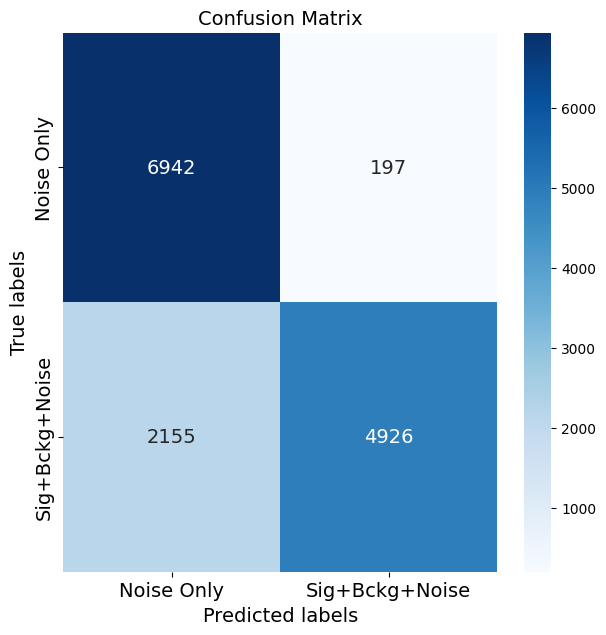

In [ ]:
import matplotlib.pyplot as plt
import os

target_dir = "/content/drive/MyDrive/project_files/Plots_no_time/"
os.makedirs(target_dir, exist_ok=True) # Crea la cartella se non esiste
plot_filename = f"{target_dir}confusion_matrix_{FREQ}kHz.png" # Nome file dinamico con FREQ

# --- Generazione e Salvataggio ---
print("Generazione Matrice di Confusione...")

# 1. Chiama la tua funzione esistente (che disegna il grafico)
confusion_matrix_image(cf_matrix)
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')

print(f"✅ Immagine salvata correttamente in: {plot_filename}")

# 3. Ora stampa le performance
print_performances(cf_matrix)

In [ ]:
def values_TPR_TNR(cf_matrix):
    true_negative = cf_matrix[0][0]
    true_positive = cf_matrix[1][1]
    false_negative = cf_matrix[1][0]
    false_positive = cf_matrix[0][1]
    TNR = true_negative/(false_positive+true_negative)
    TPR = true_positive/(false_negative+true_positive)

    return TPR,TNR

In [ ]:

ReductionFactor = 5
tnr_limit = 1-1/ReductionFactor
opt_idx = 0
thresholds = np.linspace(0, 0.5, 10000)

for th in thresholds:
    cf_matrix, index_list = confusion_matrix_indexing(y_pred,y_test,index_test,threshold=th)
    tpr,tnr = values_TPR_TNR(cf_matrix)
    if(tnr>=tnr_limit):
        opt_idx = th
        print(f"Reduction Factor {ReductionFactor} Optimized threshold (TNR>=80%): {opt_idx:.5f}")
        print_performances(cf_matrix)
        break

Reduction Factor 5 Optimized threshold (TNR>=80%): 0.00935
Purity = 0.8063552417164584
Recall = 0.8385821211693264
Accuracy = 0.819338959212377
TNR = 0.8002521361535229
TPR = 0.8385821211693264


In [ ]:
!pip install hls4ml

import hls4ml


hls4ml.model.optimizer.optimizer.layers = ['Activation']
hls4ml.model.optimizer.optimizer.rounding_mode = 'AP_RND'
hls4ml.model.optimizer.optimizer.saturation_mode = 'AP_SAT'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 14.4 MB/s eta 0:00:00


In [ ]:
print(np.asarray(model_input_train).shape)

(30, 142200, 42)


In [ ]:
################  DAM model definition #########################################################

qmodel = model

damI = []
damI_output_train = []
damI_output_test = []

sector_input_train = []
sector_input_test = []

dam_layer_name = 'fc6_'
#dam_layer_name = 'fc8_'

for sec in range(6):
    for subsec in range(5):

        input_index = subsec+sec*5
        damI_intermodel = Model(inputs=qmodel.input[input_index],
                        outputs=qmodel.get_layer(dam_layer_name+str(input_index)).output)
        damI.append(damI_intermodel)
        damI_intermodel.summary()

        damI_output_train.append(damI[input_index].predict(model_input_train[input_index], batch_size=1000))
        damI_output_test.append(damI[input_index].predict(model_input_test[input_index], batch_size=1000))

    sector_input_train.append(np.concatenate((damI_output_train[0+sec*5], damI_output_train[1+sec*5], damI_output_train[2+sec*5],
                                         damI_output_train[3+sec*5], damI_output_train[4+sec*5]), axis=-1))
    sector_input_test.append(np.concatenate((damI_output_test[0+sec*5], damI_output_test[1+sec*5], damI_output_test[2+sec*5],
                                         damI_output_test[3+sec*5], damI_output_test[4+sec*5]), axis=-1))

print(sector_input_train[0].shape)
print(sector_input_test[0].shape)

################  SECTOR model definition #########################################################


sector_mlp = []

first_layer_name = 'concatenate_'
last_layer_name = 'sector_fc6_'

sector_output_train = []
sector_output_test = []
WRONG=False
for sec in range(6):
    input_index = subsec+sec*5
    if(WRONG==True):
        sector_intermodel = Model(inputs=qmodel.get_layer('concatenate_'+str(sec+7)).output,
                        outputs=qmodel.get_layer(last_layer_name+str(sec)).output)
    else:
        sector_intermodel = Model(inputs=qmodel.get_layer(first_layer_name+str(sec)).output,
                        outputs=qmodel.get_layer(last_layer_name+str(sec)).output)
    sector_intermodel.summary()
    sector_mlp.append(sector_intermodel)
    sector_output_train.append(sector_mlp[sec].predict(sector_input_train[sec]))
    sector_output_test.append(sector_mlp[sec].predict(sector_input_test[sec]))

last_model_input_train = np.concatenate((sector_output_train[0], sector_output_train[1], sector_output_train[2],
                                         sector_output_train[3], sector_output_train[4], sector_output_train[5]), axis=-1)
last_model_input_test = np.concatenate((sector_output_test[0], sector_output_test[1], sector_output_test[2],
                                         sector_output_test[3], sector_output_test[4], sector_output_test[5]), axis=-1)

print(last_model_input_train.shape)
print(last_model_input_test.shape)

############ LAST Layer model ######################################################################

last_model = Model(inputs=qmodel.get_layer(first_layer_name+str(6)).output,
                        outputs=qmodel.get_layer('fc8_damII').output)
#last_model.summary()
last_predict_train = last_model.predict(last_model_input_train)
last_predict_test = last_model.predict(last_model_input_test)

Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input0 (InputLayer)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc4_0 (QDense)                  │ (None, 32)             │         5,634 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc5_0 (QDense)                  │ (None, 16)             │         2,212 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc6_0 (QDense)                  │ (None, 8)              │           596 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,442 (26.74 KB)

 Trainable params: 6,154 (24.04 KB)

 Non-trainable params: 2,288 (2.70 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_143CLONE           │ (None, 40)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sector_fc4_5 (QDense)           │ (None, 20)             │         3,404 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sector_fc5_5 (QDense)           │ (None, 16)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sector_fc6_5 (QDense)           │ (None, 4)              │           324 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,136 (16.25 KB)

 Trainable params: 3,708 (14.48 KB)

 Non-trainable params: 1,428 (1.77 KB)

4444/4444 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
(142200, 24)
(14220, 24)
4444/4444 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
hls4ml.model.optimizer.optimizer.layers = ['Activation']
hls4ml.model.optimizer.optimizer.rounding_mode = 'AP_RND'
hls4ml.model.optimizer.optimizer.saturation_mode = 'AP_SAT'

# Note that without the above instruction the hls accuracy drop to 25% i.e. random choice among 4 classes

#   hls_config     = hls4ml.utils.config_from_keras_model(model, granularity='model')
#   hls_config     = hls4ml.utils.config_from_keras_model(model, granularity='name')

reuse_factor=1
hls_config_sector = []
for i in range(0,6):
    hls_config_sector.append(hls4ml.utils.config_from_keras_model(sector_mlp[i], granularity='name',default_precision='fixed<-1,0>',default_reuse_factor=reuse_factor))
    hls_config_sector[i]['Model']['Strategy'] = 'distributed_arithmetic'
    #hls_config_sector[i]['Model']['PipelineStyle']='pipeline'
    hls_config_sector[i]['Model']['PipelineInterval']='1'
    hls_config_sector[i]['Model']['BRAM']='True'
    hls_config_sector[i]['Model']['PipelineStyle']='dataflow'
#hls_config_sector['Model']["BramFactor"] = 1

hls_config_dam = []
for i in range(30):
    hls_config_dam.append(hls4ml.utils.config_from_keras_model(damI[i], granularity='name',default_precision='fixed<-1,0>'
                                                      ,default_reuse_factor=reuse_factor))
    hls_config_dam[i]['Model']['Strategy'] = 'distributed_arithmetic'
    hls_config_dam[i]['Model']['PipelineStyle']='pipeline'
    hls_config_dam[i]['Model']['PipelineInterval']='1'
    hls_config_dam[i]['Model']['BRAM']='True'
    hls_config_dam[i]['Model']['PipelineStyle']='dataflow'
#hls_config_sector['Model']["BramFactor"] = 1

hls_config_last_model    = hls4ml.utils.config_from_keras_model(last_model, granularity='name',default_precision='fixed<-1,0>'
                                                      ,default_reuse_factor=reuse_factor)
hls_config_last_model['Model']['Strategy'] = 'distributed_arithmetic'
hls_config_last_model['Model']['PipelineStyle']='dataflow'
#hls_config_last_model['Model']['PipelineStyle']='pipeline'
hls_config_last_model['Model']['PipelineInterval']='1'
hls_config_last_model['Model']['BRAM']='True'
#hls_config_sector['Model']["BramFactor"] = 1

In [ ]:
hls_model_dam = []

!pip install da4ml
import da4ml

for i in range(30):
    print("####### DAM MODEL {num} ###### \n".format(num=i))
    hls_model_dam.append(hls4ml.converters.convert_from_keras_model( damI[i],  hls_config   = hls_config_dam[i],
                                    output_dir   = "hw_dam_prova_{num}".format(num=i),
                                     part    = "xcvm1802-vsva2197-1MP-e-S",#"xcu280-fsvh2892-2l-e",#'xcvm1802-vsva2197-1MP-e-S',#"xcu280-fsvh2892-2l-e",#"xcu200-fsgd2104-2-e",
                                #   fpga_part    = fpga_part,
                                    project_name = "hwfunc_DAM{num}".format(num=i),
                                    clock_period = 5,
                                    #io_type      = "io_stream",
                                    io_type      = "io_parallel",
                                    backend      = 'vitis'))
                                #   board        = 'alveo-u200')
    # Compile (i.e. write project on disk and generate a .so)
    hls_model_dam[i].compile()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 696.9/696.9 kB 18.5 MB/s eta 0:00:00
####### DAM MODEL 0 ###### 

####### DAM MODEL 1 ###### 

####### DAM MODEL 2 ###### 

####### DAM MODEL 3 ###### 

####### DAM MODEL 4 ###### 

####### DAM MODEL 5 ###### 

####### DAM MODEL 6 ###### 

####### DAM MODEL 7 ###### 

####### DAM MODEL 8 ###### 

####### DAM MODEL 9 ###### 

####### DAM MODEL 10 ###### 

####### DAM MODEL 11 ###### 

####### DAM MODEL 12 ###### 

####### DAM MODEL 13 ###### 

####### DAM MODEL 14 ###### 

####### DAM MODEL 15 ###### 

####### DAM MODEL 16 ###### 

####### DAM MODEL 17 ###### 

####### DAM MODEL 18 ###### 

####### DAM MODEL 19 ###### 

####### DAM MODEL 20 ###### 

####### DAM MODEL 21 ###### 

####### DAM MODEL 22 ###### 

####### DAM MODEL 23 ###### 

####### DAM MODEL 24 ###### 

####### DAM MODEL 25 ###### 

####### DAM MODEL 26 ###### 

####### DAM MODEL 27 ###### 

####### DAM MODEL 28 ###### 

####### DAM MODEL 29 ###### 



In [ ]:
#import os
#os.environ['PATH'] = '/opt/Xilinx/Vivado/2020.1/bin:' + os.environ['PATH']
#os.environ['PATH'] = '/opt/Xilinx/Vitis_HLS/2022.1/bin:' + os.environ['PATH']
#print(os.environ['PATH'])

In [ ]:
#hls_model_dam[0].build(reset=True,csim=False,validation=False,cosim=False, export=True,synth=True)

In [ ]:
#hls4ml.report.read_vivado_report("hw_dam_0")

In [ ]:
hls_model_sector = []

for i in range(6):
    print("####### SECTOR MODEL {num} ###### \n".format(num=i))
    hls_model_sector.append(hls4ml.converters.convert_from_keras_model( sector_mlp[i],  hls_config   = hls_config_sector[i],
                                    output_dir   = "hw_sector_prova_{num}".format(num=i),
                                     part    = "xcu280-fsvh2892-2l-e",#'xcvm1802-vsva2197-1MP-e-S',#"xcu280-fsvh2892-2l-e",#"xcu200-fsgd2104-2-e",
                                #   fpga_part    = fpga_part,
                                    project_name = "hwfunc_Sec{num}".format(num=i),
                                    clock_period = 5,
                                    #io_type      = "io_stream",
                                    io_type      = "io_parallel",
                                    backend      = 'vitis'))
                                #   board        = 'alveo-u200')
    # Compile (i.e. write project on disk and generate a .so)
    hls_model_sector[i].compile()


####### SECTOR MODEL 0 ###### 

####### SECTOR MODEL 1 ###### 

####### SECTOR MODEL 2 ###### 

####### SECTOR MODEL 3 ###### 

####### SECTOR MODEL 4 ###### 

####### SECTOR MODEL 5 ###### 



In [ ]:
#hls_model_sector[0].build(reset=True,csim=False,validation=False,cosim=False, export=True,synth=True, fifo_opt=True)

In [ ]:
#hls4ml.report.read_vivado_report("hw_sector_0")

In [ ]:
hls_mlp_last_model = []


print("####### LAST MLP MODEL {num} ###### \n".format(num=i))
hls_mlp_last_model = hls4ml.converters.convert_from_keras_model( last_model,  hls_config   = hls_config_last_model,
                                    output_dir   = "hw_last_model_prova_{num}".format(num=i),
                                     part    = "xcu280-fsvh2892-2l-e",#'xcvm1802-vsva2197-1MP-e-S',#"xcu280-fsvh2892-2l-e",#"xcu200-fsgd2104-2-e",
                                #   fpga_part    = fpga_part,
                                    project_name = "hwfunc_last",
                                    clock_period = 5,
                                    #io_type      = "io_stream",
                                    io_type      = "io_parallel",
                                    backend      = 'vitis')
                                #   board        = 'alveo-u200')
    # Compile (i.e. write project on disk and generate a .so)
hls_mlp_last_model.compile()


####### LAST MLP MODEL 5 ###### 



In [ ]:
#hls_mlp_last_model.build(reset=True,csim=False,validation=False,cosim=False, export=True,synth=True, fifo_opt=True)

In [ ]:
#hls4ml.report.read_vivado_report("hw_last_model_prova_0")

In [ ]:
hls_output_dam = []
hls4ml_output_sector = []
hls4ml_sector_input = []
for i in range(30):
    print("####### DAM MODEL {num} ###### \n".format(num=i))
    hls_output_dam.append(hls_model_dam[i].predict(np.ascontiguousarray(model_input_test[i]).astype(np.float32)))


print(np.asarray(hls_output_dam).shape)
for j in range(6):
    print("####### SECTOR MODEL {num} ###### \n".format(num=j))
    sector_input = np.concatenate((hls_output_dam[j*5],
                                   hls_output_dam[j*5+1],
                                   hls_output_dam[j*5+2],
                                   hls_output_dam[j*5+3],
                                   hls_output_dam[j*5+4],
                                  ), axis=1)
    hls4ml_sector_input.append(sector_input)
    print(np.asarray(hls4ml_sector_input).shape)
    hls4ml_output_sector.append(hls_model_sector[j].predict(hls4ml_sector_input[j]))

print(np.asarray(hls4ml_output_sector).shape)

aggregate_mlp_input = np.concatenate((hls4ml_output_sector[0],
                                   hls4ml_output_sector[1],
                                   hls4ml_output_sector[2],
                                   hls4ml_output_sector[3],
                                   hls4ml_output_sector[4],
                                   hls4ml_output_sector[5],
                                  ), axis=1)

print("####### AGGREGATE MLP MODEL ###### \n")
print(np.asarray(aggregate_mlp_input).shape)
hls4ml_pred = hls_mlp_last_model.predict(np.ascontiguousarray(aggregate_mlp_input))

####### DAM MODEL 0 ###### 

####### DAM MODEL 1 ###### 

####### DAM MODEL 2 ###### 

####### DAM MODEL 3 ###### 

####### DAM MODEL 4 ###### 

####### DAM MODEL 5 ###### 

####### DAM MODEL 6 ###### 

####### DAM MODEL 7 ###### 

####### DAM MODEL 8 ###### 

####### DAM MODEL 9 ###### 

####### DAM MODEL 10 ###### 

####### DAM MODEL 11 ###### 

####### DAM MODEL 12 ###### 

####### DAM MODEL 13 ###### 

####### DAM MODEL 14 ###### 

####### DAM MODEL 15 ###### 

####### DAM MODEL 16 ###### 

####### DAM MODEL 17 ###### 

####### DAM MODEL 18 ###### 

####### DAM MODEL 19 ###### 

####### DAM MODEL 20 ###### 

####### DAM MODEL 21 ###### 

####### DAM MODEL 22 ###### 

####### DAM MODEL 23 ###### 

####### DAM MODEL 24 ###### 

####### DAM MODEL 25 ###### 

####### DAM MODEL 26 ###### 

####### DAM MODEL 27 ###### 

####### DAM MODEL 28 ###### 

####### DAM MODEL 29 ###### 

(30, 14220, 8)
####### SECTOR MODEL 0 ###### 

(1, 14220, 40)
####### SECTOR MODEL 1 ###### 

(2, 14220, 40)
#

In [ ]:

# Test for mismatches
# HGQ2 and hls4ml should produce the same output, up to machine precision
# Notice that due to the quantization, internal mismatches may be amplified, but the vast majority of the output should match

keras_pred = model.predict(model_input_test)

print(f"{np.sum((keras_pred>0.5) != (hls4ml_pred>0.5))} / {np.prod(keras_pred.shape)} value mismatches")

445/445 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step
0 / 14220 value mismatches


In [ ]:
hls4ml_cf_matrix, hls4ml_index_list = confusion_matrix_indexing(hls4ml_pred,y_test,index_test,threshold=0.5)
print(hls4ml_cf_matrix)

[[6942.  197.]
 [2155. 4926.]]


Purity = 0.9615459691586961
Recall = 0.6956644541731394
Accuracy = 0.8345991561181435
TNR = 0.9724050987533268
TPR = 0.6956644541731394


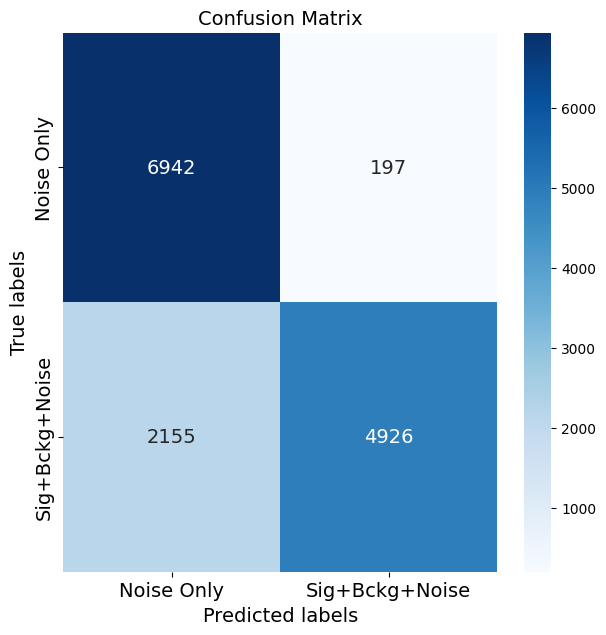

In [ ]:
confusion_matrix_image(hls4ml_cf_matrix)
print_performances(hls4ml_cf_matrix)

In [ ]:
ReductionFactor = 5
tnr_limit = 1-1/ReductionFactor
opt_idx = 0
thresholds = np.linspace(0, 0.5, 10000)

for th in thresholds:
    hls4ml_cf_matrix, hls4ml_index_list = confusion_matrix_indexing(hls4ml_pred,y_test,index_test,threshold=th)
    tpr,tnr = values_TPR_TNR(hls4ml_cf_matrix)
    if(tnr>=tnr_limit):
        hls4ml_opt_idx = th
        print(f"Reduction Factor {ReductionFactor} Optimized threshold (TNR>=80%): {hls4ml_opt_idx:.5f}")
        print_performances(hls4ml_cf_matrix)
        break

Reduction Factor 5 Optimized threshold (TNR>=80%): 0.00880
Purity = 0.8084322554236595
Recall = 0.836746222284988
Accuracy = 0.819971870604782
TNR = 0.8033338002521362
TPR = 0.836746222284988


In [ ]:
WRITE_OUTPUT_DATA = True

In [ ]:
if(WRITE_OUTPUT_DATA):
    import os

    # cartella output per i csv di noise
    OUTDIR = "intermediate_output_txt"
    os.makedirs(OUTDIR, exist_ok=True)

    for i in range(30):
        with open('intermediate_output_txt/damI_input_train_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, model_input_train[i])
        with open('intermediate_output_txt/damI_input_test_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, model_input_test[i])
        with open('intermediate_output_txt/damI_output_train_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, damI_output_train[i])
        with open('intermediate_output_txt/damI_output_test_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, damI_output_test[i])

        np.savetxt("intermediate_output_txt/damI_input_train_{num}.txt".format(num=i), model_input_train[i], fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/damI_input_test_{num}.txt".format(num=i), model_input_test[i], fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/damI_output_train_{num}.txt".format(num=i), damI_output_train[i], fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/damI_output_test_{num}.txt".format(num=i), damI_output_test[i], fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)

    for i in range(6):
        with open('intermediate_output_txt/sector_input_train_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, sector_input_train[i])
        with open('intermediate_output_txt/sector_input_test_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, sector_input_test[i])
        with open('intermediate_output_txt/sector_output_train_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, sector_output_train[i])
        with open('intermediate_output_txt/sector_output_test_{num}.npy'.format(num=i), 'wb') as f:
            np.save(f, sector_output_test[i])

        np.savetxt("intermediate_output_txt/sector_input_train_{num}.txt".format(num=i), sector_input_train[i], fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/sector_input_test_{num}.txt".format(num=i), sector_input_test[i], fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/sector_output_train_{num}.txt".format(num=i), sector_output_train[i], fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
        np.savetxt("intermediate_output_txt/sector_output_test_{num}.txt".format(num=i), sector_output_test[i], fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)



    np.savetxt("intermediate_output_txt/last_model_input_train.txt",last_model_input_train, fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/last_model_input_test.txt", last_model_input_test, fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/last_predict_train.txt", last_predict_train, fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/last_predict_test.txt", last_predict_test, fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/y_train.txt", y_train, fmt='%.16e', delimiter='\n', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)
    np.savetxt("intermediate_output_txt/y_test.txt", y_test, fmt='%.16e', delimiter='\n ', newline='\n### OUTPUT DATA ###\n')#, header=' ')#, footer='', comments='# ', encoding=None)

In [ ]:
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#

In [ ]:
FREQ=150

In [ ]:
import numpy as np

In [ ]:
target_dir = "/content/drive/MyDrive/project_files/input_no_time/"
signal_data1 = f"{target_dir}signal_data_{FREQ}kHz.npy"
noise_data1 = f"{target_dir}noise_data_{FREQ}kHz.npy"
s1=np.load(signal_data1)
n1=np.load(noise_data1)

In [ ]:
print(s1.shape)
print(n1.shape)

(79000, 30, 42)
(100000, 30, 42)


In [ ]:
print(s1.max())

35
